<a href="https://colab.research.google.com/github/yukinaga/minnano_kaggle/blob/main/section_4/02_automl_houseprices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 住宅価格の予測
AutoMLにより、住宅の価格を予測します。  
訓練済みのモデルによる予測結果は、csvファイルに保存して提出します。  

## PyCaretのインストール
AutoMLをサポートするライブラリ、PyCaretをバージョンを指定してインストールします。

In [2]:
# !pip install numpy==1.21.4 numba==0.53 # すでに入っている
!pip install pycaret
!pip install pandas-profiling==3.1.0 

  Using cached joblib-1.3.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached markupsafe-3.0.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (2.7 kB)
Using cached joblib-1.3.2-py3-none-any.whl (302 kB)
Using cached markupsafe-3.0.3-cp310-cp310-macosx_11_0_arm64.whl (12 kB)
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 2.0.1
    Uninstalling MarkupSafe-2.0.1:
      Successfully uninstalled MarkupSafe-2.0.1
  Attempting uninstall: joblib
    Found existing installation: joblib 1.0.1
    Uninstalling joblib-1.0.1:
      Successfully uninstalled joblib-1.0.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [joblib]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.1.0 requires joblib~=1.0.1, but you have joblib 1.3.2 which is incompatible.
pandas-profiling 3.1.0 requires markupsafe~=2.0.1, but you have markupsafe 3.0.3 

## Google Colabの設定
Google Colab環境でPyCaretのインタラクティブな要素を表示するためには、以下のコードを実行する必要があります。

In [3]:
# from pycaret.utils import enable_colab

# enable_colab()

## データの読み込み
以下のページから住宅価格のデータをダウロードして、「train.csv」「test.csv」をノートブック環境にアップします。  
https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data

以下のコードは、これらのデータを読み込みます。   
訓練データには住宅価格を表す"SalePrice"の列がありますが、テストデータにはありません。  
訓練済みのモデルに、テストデータを入力して判定した結果を提出することになります。  


In [4]:
# PyCaretを使用して、データの前処理、特徴量エンジニアリング、モデルのトレーニング、評価を行う


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

data_train = pd.read_csv('data/train.csv')
data_test = pd.read_csv('data/test.csv')

print('train', data_train.shape, 'test', data_test.shape)
data_train.tail()

train (1460, 81) test (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


## 環境の設定
PyCaretの環境を設定します。  
setup関数はPyCaretの環境を初期化しますが、PyCaretの他の関数を実行する前に呼び出す必要があります。      
データの型に問題が無ければ、空白を入力することで設定を完了することができます。  
  
今回のデータには一部欠損があるので、欠損データに対する対応を設定する必要があります。  
`numeric_imputation="mean"`により数値データの欠損には平均値があてがわれ、`categorical_imputation="mode"`によりカテゴリデータの欠損には最頻値があてがわれます。  

https://pycaret.readthedocs.io/en/latest/api/regression.html#pycaret.regression.setup


In [5]:
from pycaret.regression import setup

# PyCaret セットアップ（PyCaret が自動で多くの前処理を実施）
clf = setup(data=data_train, target='SalePrice', session_id=123, # 再現性のためのセッションIDを指定(こういうもの)
            numeric_imputation='mean', categorical_imputation='mode', # 数値データの欠損値は平均値で、カテゴリデータの欠損値は最頻値で補完
            fold=5, log_experiment=False) # セットアップの実行。fold=5は交差検証の分割数を指定、silent=Trueはユーザーの確認を求めない(PyCaret3.3では使えない削除)log_experiment=Falseは実験のログを記録しないことを意味する

,Description,Value
0,Session id,123
1,Target,SalePrice
2,Target type,Regression
3,Original data shape,"(1460, 81)"
4,Transformed data shape,"(1460, 279)"
5,Transformed train set shape,"(1021, 279)"
6,Transformed test set shape,"(439, 279)"
7,Numeric features,37
8,Categorical features,43
9,Rows with missing values,100.0%


## モデルの比較
様々なモデルを比較して、性能を評価します。  
compare_models関数は、ライブラリ内のすべてのモデルを使って訓練を行い、スコアを評価します。  

In [6]:
from pycaret.regression import compare_models

# 全モデル比較（時間がかかるため必要に応じて n_select や include を指定）
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,17610.8152,1030086750.2744,31240.1246,0.8501,0.1433,0.1012,0.1120
lightgbm,Light Gradient Boosting Machine,18361.0765,1101174748.7878,32603.5340,0.8367,0.1509,0.1056,0.5320
et,Extra Trees Regressor,19268.9506,1156064068.3511,33486.1708,0.8277,0.1539,0.1106,0.1340
rf,Random Forest Regressor,19228.2070,1207111428.8439,34145.2393,0.8210,0.1594,0.1130,0.1340
ada,AdaBoost Regressor,25019.6148,1440045401.5890,37411.2290,0.7853,0.2015,0.1603,0.0820
llar,Lasso Least Angle Regression,19761.3008,1489867800.2773,37406.5856,0.7743,0.1802,0.1152,0.0500
ridge,Ridge Regression,20268.0233,1566759761.0640,38680.7324,0.7527,0.2424,0.1210,0.2400
en,Elastic Net,21689.6115,1854879308.2719,41168.7343,0.7179,0.1839,0.1251,0.2680
omp,Orthogonal Matching Pursuit,23333.7236,1905586254.9933,41834.0151,0.7093,0.2018,0.1393,0.2280
dt,Decision Tree Regressor,30062.3479,2190243326.4234,46674.5578,0.6598,0.2207,0.1682,0.0500


わずか1行のコードで、15以上の機械学習モデルを訓練し、評価することができました。  
  
最もスコアの良いモデルの概要を表示します。


In [7]:
print(best_model)

GradientBoostingRegressor(random_state=123)


## モデルの作成
models関数により、全ての使用可能な機械学習モデルを確認することができます。

In [8]:
from pycaret.regression import models

models()  # 機械学習モデルの一覧

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.Elast...,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPu...,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


create_model関数は、「交差検証」を用いて個別のモデルの訓練と評価を行います。  
今回は、先程最も精度が高かった「勾配ブースティング」による回帰（Gradient Boosting Regressor）のモデルを作成します。  


In [9]:
from pycaret.regression import create_model

gbr = create_model("gbr")  # 勾配ブースティングのモデルを作成

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,19248.3077,1302602274.2560,36091.5818,0.8217,0.1546,0.1039
1,15040.9919,524750932.2843,22907.4427,0.8930,0.1268,0.0916
2,19091.9268,1857705416.4230,43101.1069,0.7821,0.1662,0.1107
3,17474.5251,679356405.5161,26064.4663,0.8823,0.1339,0.1013
4,17198.3245,786018722.8928,28036.0254,0.8714,0.1352,0.0983
Mean,17610.8152,1030086750.2744,31240.1246,0.8501,0.1433,0.1012
Std,1527.5987,489318430.6842,7358.0815,0.0419,0.0147,0.0063


訓練済みモデルの概要を表示します。  

In [10]:
print(gbr)

GradientBoostingRegressor(random_state=123)


## ハイパーパラメータの調整
tune_model関数を使用し、ハイパーパラメータを最適化します。

In [11]:
from pycaret.regression import tune_model

tuned_gbr = tune_model(gbr)  # ハイパーパラメータの調整

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,21045.3766,1917894436.4992,43793.7717,0.7375,0.1732,0.1138
1,17056.2392,633851639.2843,25176.4104,0.8708,0.1388,0.1039
2,19142.8549,1580649142.5192,39757.3785,0.8146,0.1695,0.1139
3,18729.6923,822410829.2839,28677.7061,0.8575,0.1449,0.1077
4,17838.6841,1144655583.9444,33832.7590,0.8128,0.1456,0.1012
Mean,18762.5694,1219892326.3062,34247.6051,0.8186,0.1544,0.1081
Std,1350.7060,474225309.5311,6855.2074,0.0466,0.0141,0.0051


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


ハイパーパラメータを調整済みの、モデルの概要を表示します。  

In [12]:
print(tuned_gbr)

GradientBoostingRegressor(random_state=123)


## モデルを評価する
plot_model関数を使い、各特徴量の重要度をプロットします。

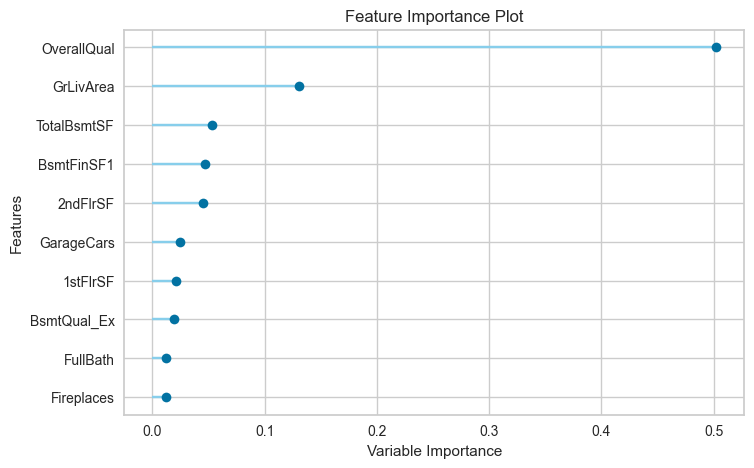

In [13]:
from pycaret.regression import plot_model

plot_model(tuned_gbr, plot="feature")  # 各特徴の重要度をプロット

## 本番用のモデルを作成
`finalize_model`関数により全ての訓練データを使ってモデルを訓練し、本番用のモデルを作成します。   

In [14]:
from pycaret.regression import finalize_model

final_gbr = finalize_model(tuned_gbr)
print(final_gbr)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['Id', 'MSSubClass', 'LotFrontage',
                                             'LotArea', 'OverallQual',
                                             'OverallCond', 'YearBuilt',
                                             'YearRemodAdd', 'MasVnrArea',
                                             'BsmtFinSF1', 'BsmtFinSF2',
                                             'BsmtUnfSF', 'TotalBsmtSF',
                                             '1stFlrSF', '2ndFlrSF',
                                             'LowQualFinSF', 'GrLivArea',
                                             'BsmtFullBath', 'BsmtHalfBath',
                                             'FullBath', 'Hal...
                                                                    'Exterior1st',
                                                                    'Exterior2nd',
                           

## 提出用のデータを作成
テストデータを使って予測を行います。  
予測結果には、予測値を表す「Label」列が含まれます。

In [16]:
from pycaret.regression import predict_model

test_pred = predict_model(final_gbr, data=data_test)  # 予測
test_pred.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,prediction_label
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,121113.166464
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,164679.386752
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,177012.878897
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,182521.630713
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,198647.726294


形式を整えた上で、Kaggleに提出するためのcsvファイルを保存します。

In [20]:
# 形式を整える
subm_data = test_pred[["Id", "prediction_label"]]  # 列を抜き出す
subm_data = subm_data.rename(columns={"prediction_label": "SalePrice"})  # 列名の変更

# 提出用のcsvファイルを保存
subm_data.to_csv("submission_houseprices.csv", index=False)

subm_data


,Id,SalePrice
0,1461,121113.166464
1,1462,164679.386752
2,1463,177012.878897
3,1464,182521.630713
4,1465,198647.726294
...,...,...
1454,2915,74299.628240
1455,2916,85018.812424
1456,2917,156887.333937
1457,2918,118078.983982
